In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("/content/Dataset .csv")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset loaded successfully!
Shape: (9551, 21)
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shan

Top 3 Most Common Cuisines
1. North Indian         Count: 3960   (41.46%)
2. Chinese              Count: 2735   (28.64%)
3. Fast Food            Count: 1986   (20.79%)


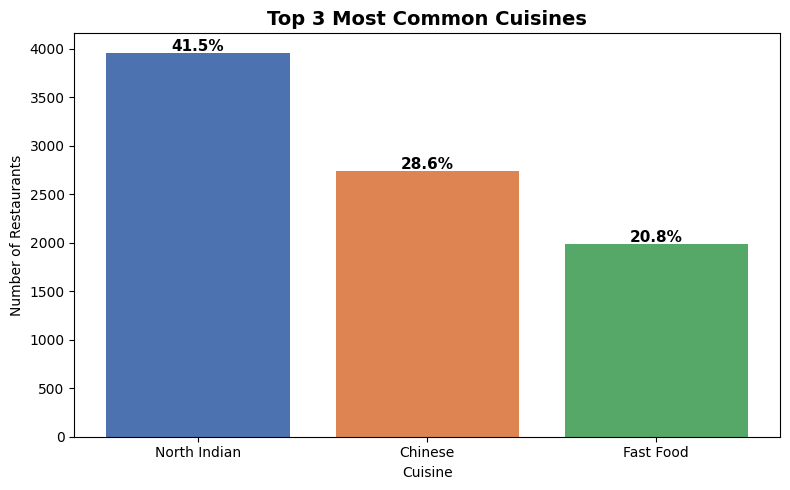

In [ ]:
# Level 1 - Task 1: Top Cuisines

total = len(df)
all_cuisines = []
for entry in df["Cuisines"].dropna():
    for cuisine in entry.split(","):
        all_cuisines.append(cuisine.strip())

cuisine_counts = Counter(all_cuisines)
top3 = cuisine_counts.most_common(3)

print("Top 3 Most Common Cuisines")
print("=" * 40)
for rank, (cuisine, count) in enumerate(top3, 1):
    pct = (count / total) * 100
    print(f"{rank}. {cuisine:<20} Count: {count}   ({pct:.2f}%)")

names  = [c[0] for c in top3]
counts = [c[1] for c in top3]
pcts   = [(c / total) * 100 for c in counts]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, counts, color=["#4C72B0", "#DD8452", "#55A868"])
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Top 3 Most Common Cuisines", fontsize=14, fontweight="bold")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

City with Most Restaurants: New Delhi (5473)

City with Highest Avg Rating: Inner City (4.90)



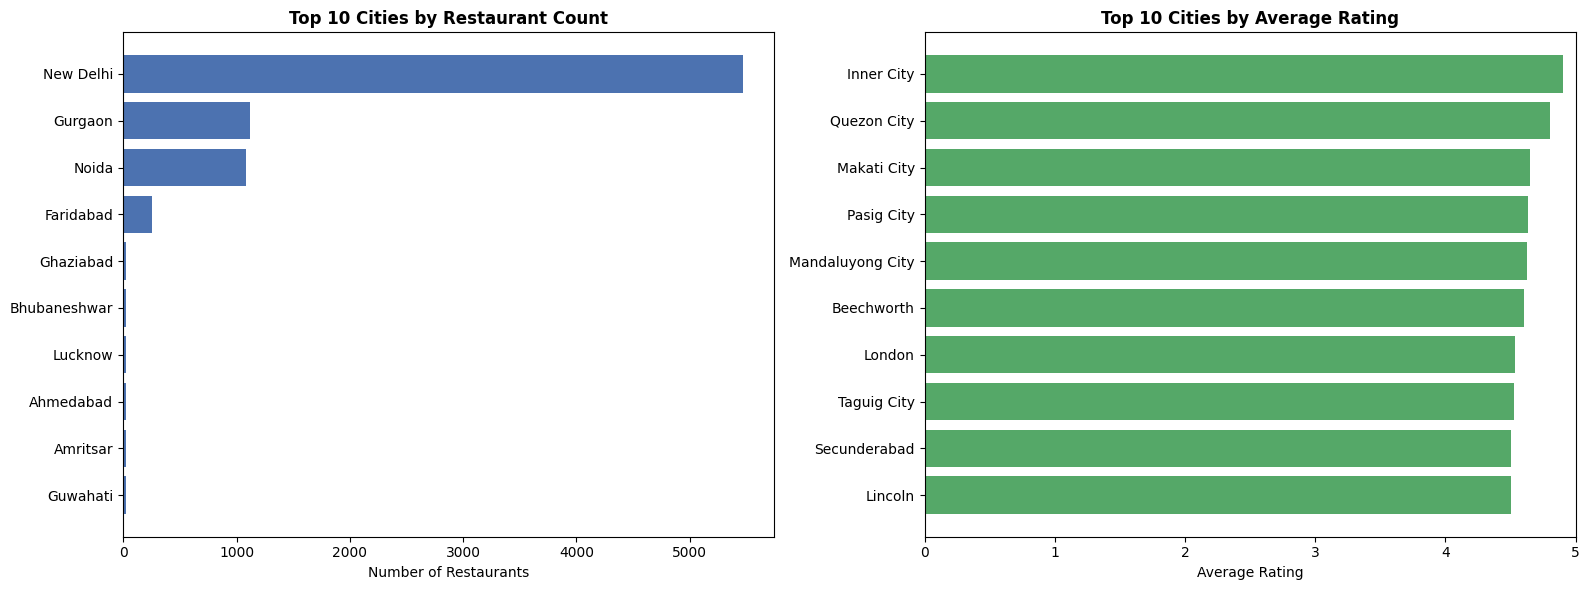

In [ ]:
# Level 1 - Task 2: City Analysis

city_counts = df["City"].value_counts()
print(f"City with Most Restaurants: {city_counts.idxmax()} ({city_counts.max()})\n")

rated = df[df["Aggregate rating"] > 0]
city_avg = rated.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
print(f"City with Highest Avg Rating: {city_avg.idxmax()} ({city_avg.max():.2f})\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = city_counts.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color="#4C72B0")
axes[0].set_title("Top 10 Cities by Restaurant Count", fontweight="bold")
axes[0].set_xlabel("Number of Restaurants")

top10_rated = city_avg.head(10)
axes[1].barh(top10_rated.index[::-1], top10_rated.values[::-1], color="#55A868")
axes[1].set_title("Top 10 Cities by Average Rating", fontweight="bold")
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

Price Range Distribution
  Budget       Count: 4444   (46.53%)
  Moderate     Count: 3113   (32.59%)
  Premium      Count: 1408   (14.74%)
  Luxury       Count: 586   (6.14%)


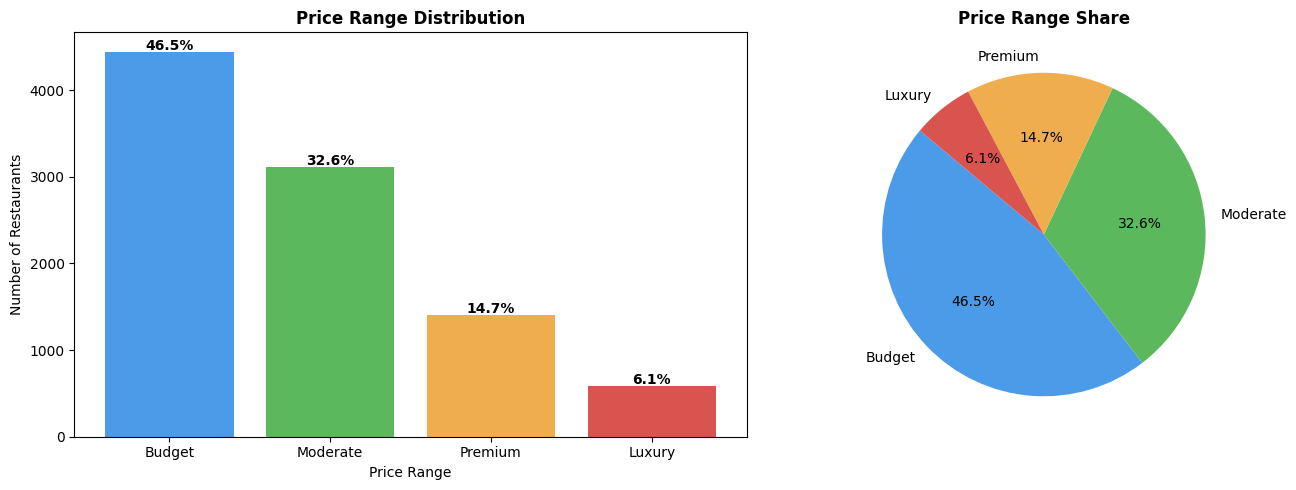

In [ ]:
# Level 1 - Task 3: Price Range Distribution

total = len(df)
price_labels = {1: "Budget", 2: "Moderate", 3: "Premium", 4: "Luxury"}
price_dist = df["Price range"].value_counts().sort_index()
price_pct  = (price_dist / total * 100).round(2)

print("Price Range Distribution")
print("=" * 45)
for pr, cnt in price_dist.items():
    print(f"  {price_labels[pr]:<12} Count: {cnt}   ({price_pct[pr]:.2f}%)")

colors = ["#4C9BE8", "#5CB85C", "#F0AD4E", "#D9534F"]
labels = [price_labels[i] for i in price_dist.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(labels, price_dist.values, color=colors)
for bar, pct in zip(bars, price_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f"{pct:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("Price Range Distribution", fontweight="bold")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Number of Restaurants")

axes[1].pie(price_dist.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Price Range Share", fontweight="bold")

plt.tight_layout()
plt.show()

With Online Delivery   : 2451 (25.66%)
Without Online Delivery: 7100 (74.34%)

Avg Rating WITH delivery   : 3.38
Avg Rating WITHOUT delivery: 3.47


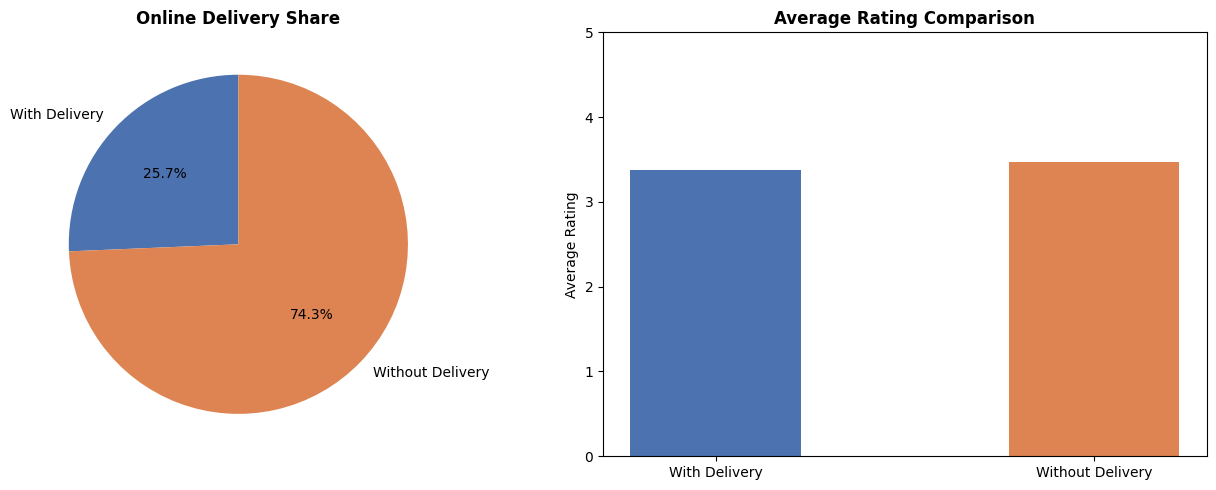

In [ ]:
# Level 1 - Task 4: Online Delivery

total = len(df)
delivery_counts = df["Has Online delivery"].value_counts()
has_del = delivery_counts.get("Yes", 0)
no_del  = delivery_counts.get("No", 0)

print(f"With Online Delivery   : {has_del} ({has_del/total*100:.2f}%)")
print(f"Without Online Delivery: {no_del} ({no_del/total*100:.2f}%)")

rated = df[df["Aggregate rating"] > 0]
avg_with    = rated[rated["Has Online delivery"] == "Yes"]["Aggregate rating"].mean()
avg_without = rated[rated["Has Online delivery"] == "No"]["Aggregate rating"].mean()
print(f"\nAvg Rating WITH delivery   : {avg_with:.2f}")
print(f"Avg Rating WITHOUT delivery: {avg_without:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([has_del, no_del],
            labels=["With Delivery", "Without Delivery"],
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], startangle=90)
axes[0].set_title("Online Delivery Share", fontweight="bold")

axes[1].bar(["With Delivery", "Without Delivery"],
            [avg_with, avg_without], color=["#4C72B0", "#DD8452"], width=0.45)
axes[1].set_ylim(0, 5)
axes[1].set_title("Average Rating Comparison", fontweight="bold")
axes[1].set_ylabel("Average Rating")
plt.tight_layout()
plt.show()